In [ ]:
!pip install argparse pathlib torch tqdm numpy pandas

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# go to project dir
%cd /content

# copy the code and data zip
!rsync -av /content/drive/MyDrive/c3_ldm_train/ ./c3_ldm_train_local

%cd /content/c3_ldm_train_local
!ls

%cd /content/c3_ldm_train_local/

/content
sending incremental file list
created directory ./c3_ldm_train_local
./
.gitignore
C3-LDM.md
IMPLEMENTATION_ROADMAP.md
README.md
README_IMPLEMENTATION.md
colab_training.ipynb
create_pairing.py
data.tar.gz
dataset.py
inference.py
train.py
checkpoints_wp/
checkpoints_wp/checkpoint_best.pt
checkpoints_wp/checkpoint_epoch0027_step00010152.pt
checkpoints_wp/checkpoint_epoch0029_step00010904.pt
checkpoints_wp/checkpoint_epoch0030_step00011280.pt
checkpoints_wp/checkpoint_latest.pt
checkpoints_wp/metadata_epoch0027_step00010152.json
checkpoints_wp/metadata_epoch0029_step00010904.json
checkpoints_wp/metadata_epoch0030_step00011280.json
eval_wp/
eval_wp/epoch10_idx005000.npy
eval_wp/epoch10_idx005000.png
eval_wp/epoch10_idx007500.npy
eval_wp/epoch10_idx007500.png
eval_wp/epoch10_idx008150.npy
eval_wp/epoch10_idx008150.png
eval_wp/epoch10_idx013850.npy
eval_wp/epoch10_idx013850.png
eval_wp/epoch10_idx022000.npy
eval_wp/epoch10_idx022000.png
eval_wp/epoch15_idx005000.npy
eval_wp/epoch15_

In [3]:
# unzip data here in runtime memo
!tar -xzf data.tar.gz
!ls data

dataset.py  GHS_POP  HRSL  paired_dataset  tiles_2020


In [ ]:
# Create train/test split if not already exists
import os
if not os.path.exists("data/paired_dataset/train_split.csv"):
    print("Creating stratified train/test split...")
    !python create_train_test_split.py \
        --products WorldPop \
        --test_size 0.2 \
        --random_state 42 \
        --min_pop_threshold 1.0
    print("\nTrain/test split created!")
else:
    print("Train/test split already exists. Skipping creation.")
    !ls -lh data/paired_dataset/*.csv

In [ ]:
# !rm -rf checkpoints
!rm -rf /content/c3_ldm_train_local/checkpoints_wp/

In [5]:
# save checkpoints in drive, not runtime local (cause checkpoint loss when colab stop runtime on backend)
import os, pathlib

CKPT_DIR = "/content/drive/MyDrive/c3_ldm_train/checkpoints_wp"    # modify this address
# CKPT_DIR = "./checkpoints_v2"    # local running address
pathlib.Path(CKPT_DIR).mkdir(parents=True, exist_ok=True)
print("Checkpoint dir:", CKPT_DIR)

EVAL_DIR = "/content/drive/MyDrive/c3_ldm_train/eval_wp"
pathlib.Path(EVAL_DIR).mkdir(parents=True, exist_ok=True)
print("Eval dir:", EVAL_DIR)

Checkpoint dir: /content/drive/MyDrive/c3_ldm_train/checkpoints_wp
Eval dir: /content/drive/MyDrive/c3_ldm_train/eval_wp


In [6]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100-SXM4-40GB


In [ ]:
!python train.py \
    --pairing_csv data/paired_dataset/train_split.csv \
    --batch_size 64 \
    --num_epochs 30 \
    --checkpoint_dir "$CKPT_DIR" \
    --data_root data \
    --eval_every 5 \
    --eval_output_dir "$EVAL_DIR" \
    --products WorldPop \
    --vae_warmup_epochs 10 \
    --kl_warmup_epochs 15 \
    --lambda_vae_recon 100.0 \
    --beta_kl 0.001 \
    --lr 1e-4

In [7]:
!rsync -av "$EVAL_DIR" ./c3_ldm_train_local

sending incremental file list
created directory ./c3_ldm_train_local
eval_wp/
eval_wp/epoch10_idx005000.npy
eval_wp/epoch10_idx005000.png
eval_wp/epoch10_idx007500.npy
eval_wp/epoch10_idx007500.png
eval_wp/epoch10_idx008150.npy
eval_wp/epoch10_idx008150.png
eval_wp/epoch10_idx013850.npy
eval_wp/epoch10_idx013850.png
eval_wp/epoch10_idx022000.npy
eval_wp/epoch10_idx022000.png
eval_wp/epoch15_idx005000.npy
eval_wp/epoch15_idx005000.png
eval_wp/epoch15_idx007500.npy
eval_wp/epoch15_idx007500.png
eval_wp/epoch15_idx008150.npy
eval_wp/epoch15_idx008150.png
eval_wp/epoch15_idx013850.npy
eval_wp/epoch15_idx013850.png
eval_wp/epoch15_idx022000.npy
eval_wp/epoch15_idx022000.png
eval_wp/epoch20_idx005000.npy
eval_wp/epoch20_idx005000.png
eval_wp/epoch20_idx007500.npy
eval_wp/epoch20_idx007500.png
eval_wp/epoch20_idx008150.npy
eval_wp/epoch20_idx008150.png
eval_wp/epoch20_idx013850.npy
eval_wp/epoch20_idx013850.png
eval_wp/epoch20_idx022000.npy
eval_wp/epoch20_idx022000.png
eval_wp/epoch25_idx005

In [1]:
!python inference.py \
  --checkpoint "checkpoints_wp/checkpoint_best.pt" \
  --condition data/tiles_2020/project/tiles_2020/features_012345.npy \
  --product_id 0 \
  --sampler ddpm \
  --num_steps 50 \
  --output outputs/worldpop_012345.npy



C3-LDM Inference

Loading inputs...
  Condition shape: (2, 256, 256)
  Normalized condition range per channel: ch0 [0, 1], ch1 [0, 1]
Loading models from: checkpoints_wp/checkpoint_best.pt
  Loaded vae
  Loaded time_emb
  Loaded cond_encoder
  Loaded product_emb
  Loaded unet

Generating population maps...
  Product ID: 0
  Sampler: ddpm
  Num samples: 1
DDPM Sampling: 100%|███████████████████████| 1000/1000 [00:08<00:00, 116.34it/s]

=== INFERENCE Diagnostics ===
z_0 range: [-8.283, 8.541], mean=-0.074, std=2.302
Residual range: [-4.325, -0.328], mean=-0.714
Baseline range: [0.000100, 1.018459], sum=44.79
exp(residual) range: [0.0132, 0.7205]
pop_raw range: [0.0000, 0.0570], sum=7.08

Saving output to: outputs/worldpop_012345.npy
  Output shape: (1, 1, 256, 256)
  Population range: [0.00, 0.06]
  Total population: 7

✓ Inference completed!


In [ ]:
# !python inference.py \
#       --checkpoint checkpoints/checkpoint_best.pt \
#       --condition data/tiles_2020/project/tiles_2020/features_013085.npy \
#       --product_id 1 \
#       --num_samples 1 \
#       --sampler ddpm --num_steps 50 --eta 0.0 \
#       --output outputs/pred_1_013085.npy

In [17]:
import torch
from models import BaselineDasymetric

device = "cuda" if torch.cuda.is_available() else "cpu"
baseline_model = BaselineDasymetric().to(device).eval()

def show_tile(idx, product_id=0, file_name="", scale_truth=True):

    cond = np.load(f"data/tiles_2020/project/tiles_2020/features_{idx:06d}.npy")     # (2,256,256)
    # change gt load address for other products
    gt   = np.load(f"data/tiles_2020/project/tiles_2020/target_{idx:06d}.npy")       # (1,256,256)

    # cond = load_cond(idx)          # (2,256,256)
    # gt   = load_gt(idx, product_id)  # (1,256,256)
    gt   = gt[0]                   # (256,256)

    if file_name != "":
        pred = np.load(file_name)
        if pred.ndim == 3:
            pred = pred[0]

        # === ADD THIS: Auto-rescale to match GT sum ===
        scale_factor = gt.sum() / (pred.sum() + 1e-6)
        pred = pred * scale_factor
        print(f"Auto-rescaled pred by factor {scale_factor:.2f}")
        # ==============================================

    else:
        pred = np.load(f"output/pred_{idx:06d}.npy")[0,0]

    # -------- 1. baseline（关键：lights / settlement 的 normalize 和训练一致） --------
    # cond 形状：(2,256,256)
    viirs = cond[0]
    wsf   = cond[1]

    def _normalize(x, eps=1e-6):
        x_min = x.min()
        x_max = x.max()
        if x_max - x_min < eps:
            return np.zeros_like(x)
        return (x - x_min) / (x_max - x_min + eps)

    viirs_norm = _normalize(viirs)[None, None, ...]  # (1,1,256,256)
    wsf_norm   = _normalize(wsf)[None, None, ...]

    lights = torch.from_numpy(viirs_norm).float().to(device)
    sett   = torch.from_numpy(wsf_norm).float().to(device)

    with torch.no_grad():
        baseline = baseline_model(lights, sett).cpu().numpy()[0, 0]

    '''
    lights = torch.from_numpy(cond[0:1]).unsqueeze(0).float().to(device)  # (1,1,256,256)
    sett   = torch.from_numpy(cond[1:2]).unsqueeze(0).float().to(device)  # (1,1,256,256)

    with torch.no_grad():
        baseline = baseline_model(lights, sett).cpu().numpy()[0,0]  '''      # (256,256)

    # -------- 2. 统一颜色尺度：用 GT 的分布做 vmin/vmax --------
    positive_gt = gt[gt > 0]
    if positive_gt.size > 0:
        gt_vmin, gt_vmax = np.percentile(positive_gt, [1, 99])
    else:
        gt_vmin, gt_vmax = 0.0, 1.0
    if scale_truth:
        pred_vmin, pred_vmax = gt_vmin, gt_vmax

    else:
        pred_vmin, pred_vmax = np.percentile(pred, [1, 99])

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # VIIRS
    axes[0].imshow(cond[0], cmap="viridis")
    axes[0].set_title(f"VIIRS {idx}")
    axes[0].axis("off")

    # WSF
    axes[1].imshow(cond[1], cmap="viridis")
    axes[1].set_title("WSF")
    axes[1].axis("off")

    # Baseline
    #im_base = axes[2].imshow(baseline, cmap="viridis",
                             #vmin=gt_vmin, vmax=gt_vmax)
    #axes[2].set_title("Baseline")
    #fig.colorbar(im_base, ax=axes[2], fraction=0.046, pad=0.04)

    # Ground Truth
    im_gt = axes[2].imshow(gt, cmap="viridis",
                           vmin=gt_vmin, vmax=gt_vmax)
    axes[2].set_title("Ground Truth (WorldPop)")
    fig.colorbar(im_gt, ax=axes[2], fraction=0.046, pad=0.04)

    # Prediction
    im_pred = axes[3].imshow(pred, cmap="viridis",
                             vmin=pred_vmin, vmax=pred_vmax)
    axes[3].set_title("C3-LDM Prediction")
    fig.colorbar(im_pred, ax=axes[3], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(f"tile_{idx}.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("GT sum / max:", gt.sum(),   gt.max())
    print("Baseline sum / max:", baseline.sum(), baseline.max())
    print("Pred sum / max:", pred.sum(), pred.max())
    print("Correlation GT vs Pred:", np.corrcoef(gt.flatten(), pred.flatten())[0,1])


Auto-rescaled pred by factor 5.66


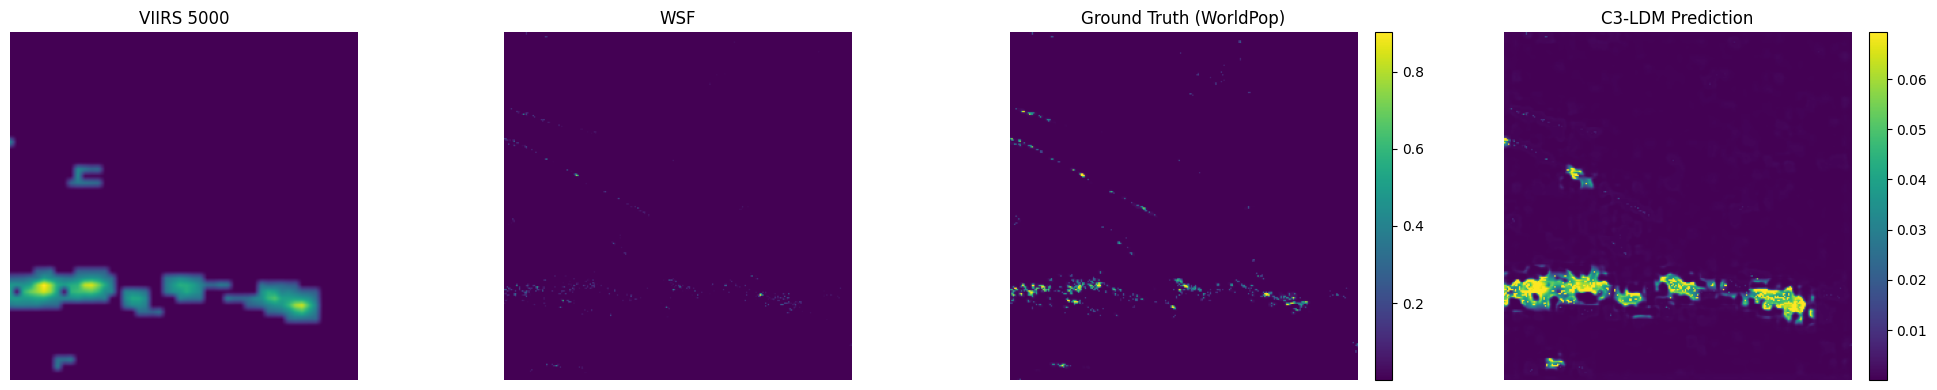

GT sum / max: 338.59464 2.088134
Baseline sum / max: 50.471622 0.6098135
Pred sum / max: 338.5946 4.299805
Correlation GT vs Pred: 0.6953521755468226
Auto-rescaled pred by factor 26.96


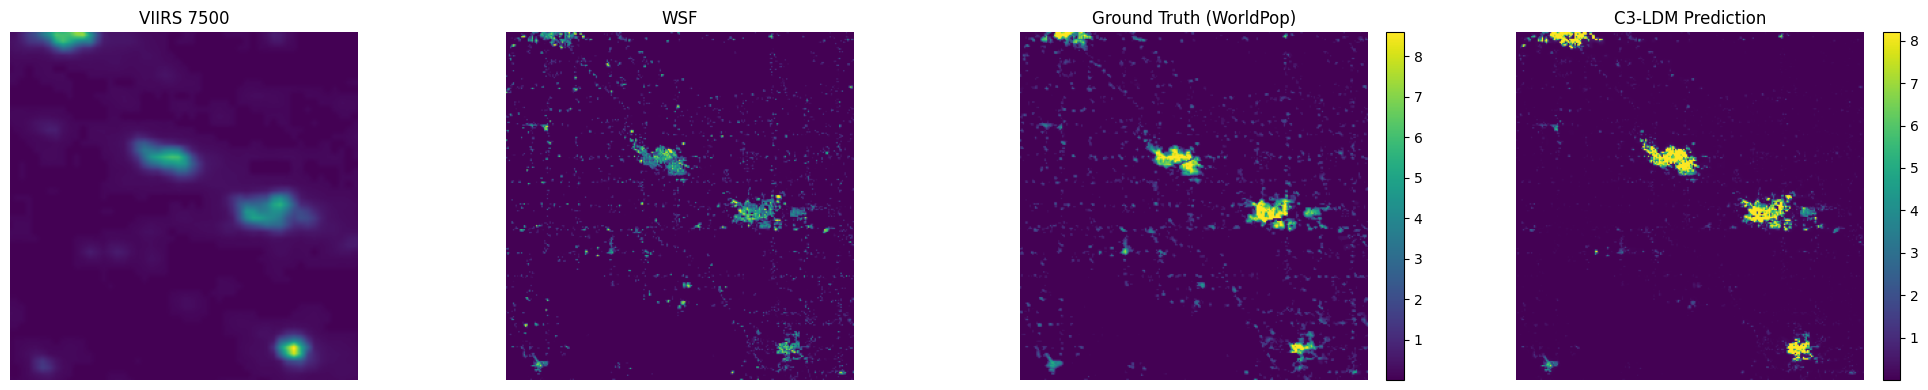

GT sum / max: 16204.61 13.736041
Baseline sum / max: 384.86154 0.84294456
Pred sum / max: 16204.61 41.193172
Correlation GT vs Pred: 0.792410916172222
Auto-rescaled pred by factor 5.88


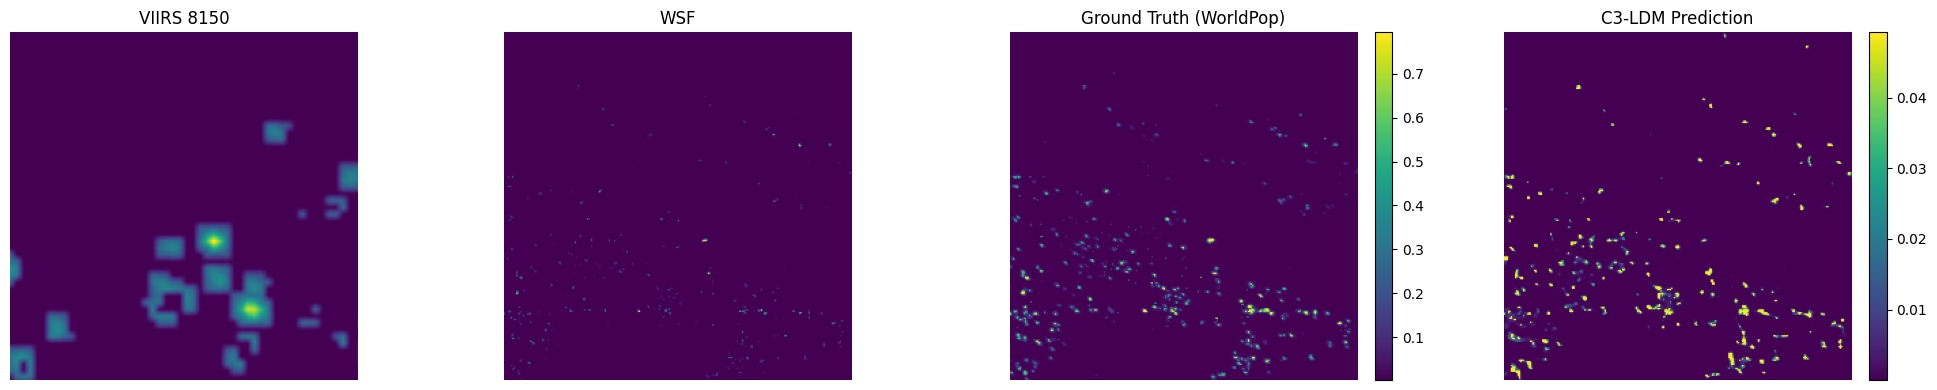

GT sum / max: 560.5966 1.779802
Baseline sum / max: 42.233814 0.87308687
Pred sum / max: 560.5967 49.22915
Correlation GT vs Pred: 0.2577216971400722
Auto-rescaled pred by factor 72.09


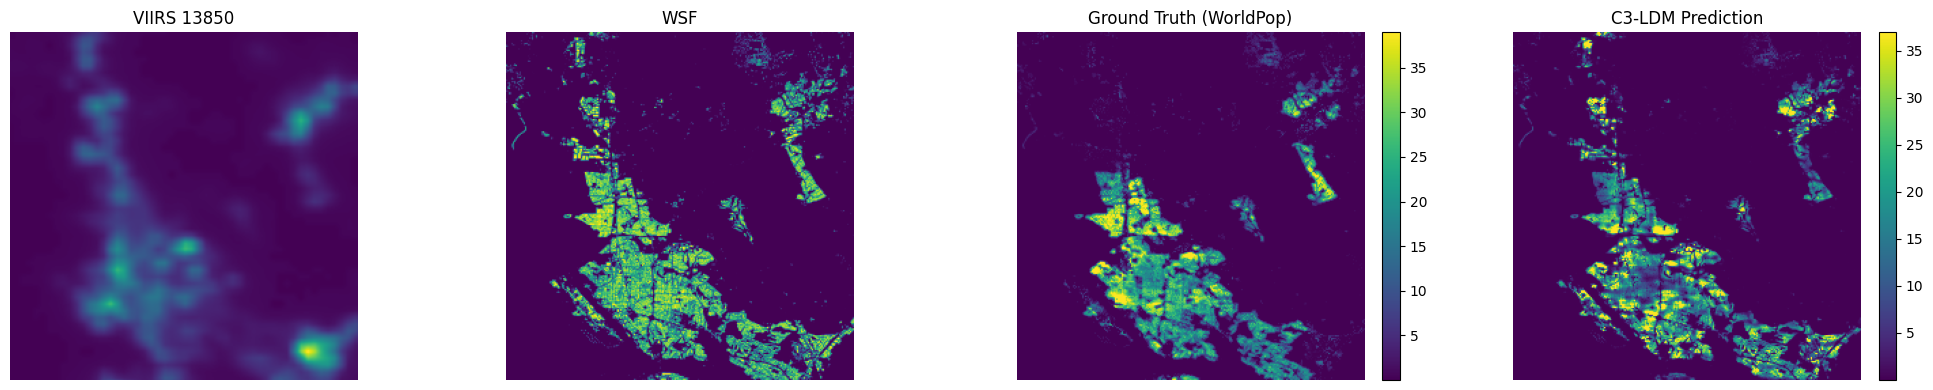

GT sum / max: 214433.19 66.25807
Baseline sum / max: 1685.0737 0.7838873
Pred sum / max: 214433.2 92.08958
Correlation GT vs Pred: 0.7363983165192722
Auto-rescaled pred by factor 105.92


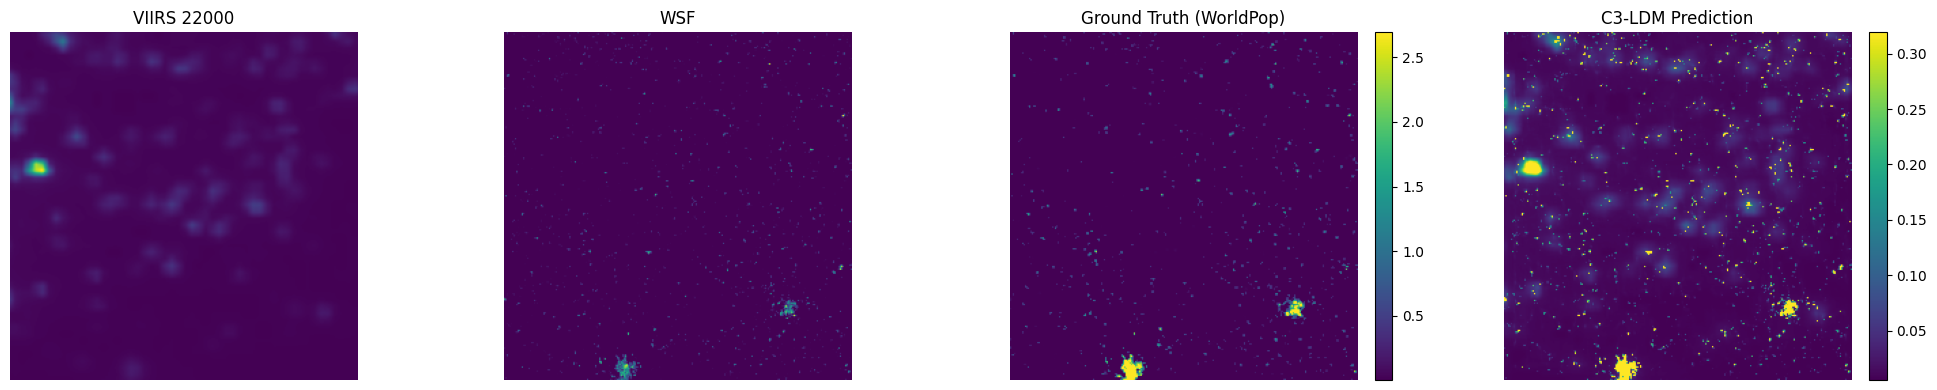

GT sum / max: 1791.2466 9.039858
Baseline sum / max: 31.381813 0.09660117
Pred sum / max: 1791.2463 4.2483635
Correlation GT vs Pred: 0.7787157651252667


In [18]:
import numpy as np
import matplotlib.pyplot as plt

for idx in [5000, 7500, 8150, 13850, 22000]:
    show_tile(idx, file_name=f"/content/drive/MyDrive/c3_ldm_train/eval_wp/epoch30_idx{idx:06d}.npy", scale_truth=False)
    #show_tile(22000, file_name="/content/c3_ldm_train_local/c3_ldm_train/c3_ldm_train_local/eval_wp/epoch20_idx022000.npy", scale_truth=False)


In [ ]:
import numpy as np

paths = ["content/c3_ldm_train_local/c3_ldm_train/outputs/pred_1_013085.npy", "outputs/worldpop_012345.npy", "data/tiles_2020/project/tiles_2020/target_001405.npy"]
for path in paths:
    arr = np.load(path)
    print("file:", path)
    print("shape:", arr.shape)
    print("min:", arr.min(), "max:", arr.max(), "mean:", arr.mean())
    print("nonzero count:", np.count_nonzero(arr))

FileNotFoundError: [Errno 2] No such file or directory: 'content/c3_ldm_train_local/c3_ldm_train/outputs/pred_1_013085.npy'

shape: (1, 1, 256, 256)


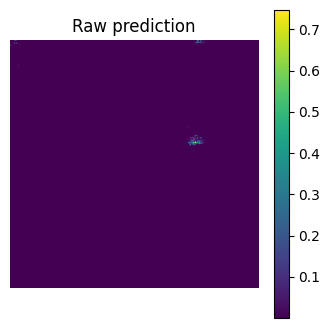

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


arr = np.load("./outputs/worldpop_012345.npy")

print("shape:", arr.shape)

# 形状通常可能是 (num_samples, 1, 256, 256) 或 (1, 256, 256)
if arr.ndim == 4:
    img = arr[0, 0]
elif arr.ndim == 3:
    img = arr[0]
else:
    img = arr

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="viridis")
plt.colorbar()
plt.title("Raw prediction")
plt.axis("off")
plt.show()
